 # Clustering Analysis (KMeans)

 ## Mục tiêu
 - Phân nhóm học sinh dựa trên đặc điểm học tập
 - Phát hiện các nhóm học sinh có nguy cơ rớt
 - Hỗ trợ giáo viên đưa ra biện pháp can thiệp

In [12]:
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("../data/processed/student_encoded.csv")

df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


Dữ liệu đã được encoding trước đó để đảm bảo tất cả các biến đều ở dạng số,
phù hợp với thuật toán KMeans.

## Remove Target Variable
Không sử dụng biến "pass" trong clustering

In [14]:
X = df.drop("pass", axis=1)

## Feature Scaling


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow Method
 Xác định số cụm tối ưu

In [16]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)



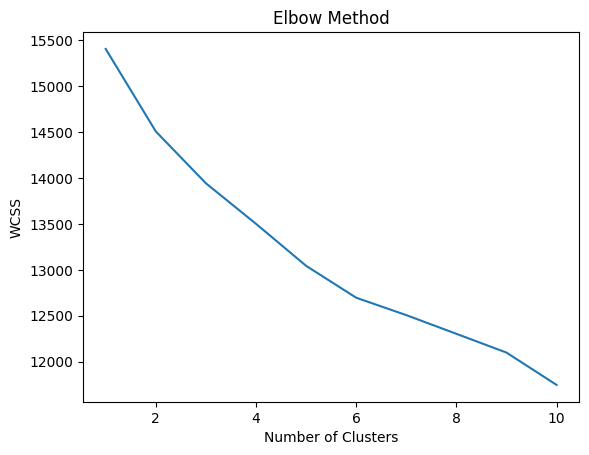

In [17]:
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


### Lựa chọn số cụm (k)

Sử dụng phương pháp Elbow, ta quan sát thấy tại k = 3
đường WCSS bắt đầu giảm chậm lại → đây là điểm gãy (elbow point).

Do đó, chọn k = 3 là hợp lý để cân bằng giữa độ phức tạp và chất lượng phân cụm.

## Train KMeans Model

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,cluster
0,18,4,4,2,2,0,4,3,4,1,...,False,True,False,False,False,True,True,False,False,1
1,17,1,1,1,2,0,5,3,3,1,...,False,False,True,False,False,False,True,True,False,0
2,15,1,1,1,2,3,4,3,2,2,...,False,True,False,True,False,True,True,True,False,0
3,15,4,2,1,3,0,3,2,2,1,...,False,False,True,True,True,True,True,True,True,1
4,16,3,3,1,2,0,4,3,2,1,...,False,False,True,True,False,True,True,False,False,0


## Evaluate Clustering

In [19]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

# Đánh giá nhanh
if score > 0.5:
    print("Clustering tốt")
elif score > 0.3:
    print("Clustering chấp nhận được")
else:
    print("Clustering chưa rõ ràng")


Silhouette Score: 0.052569833565669445
Clustering chưa rõ ràng


## Analyze Clusters

In [20]:
cluster_analysis = df.groupby("cluster")[["absences","studytime","failures"]].mean()
print(cluster_analysis)

cluster_analysis


         absences  studytime  failures
cluster                               
0        6.112299   2.278075  0.256684
1        5.160305   2.030534  0.106870
2        5.662338   1.454545  0.909091


,absences,studytime,failures
cluster,,,
0,6.112299,2.278075,0.256684
1,5.160305,2.030534,0.106870
2,5.662338,1.454545,0.909091


## Visualization

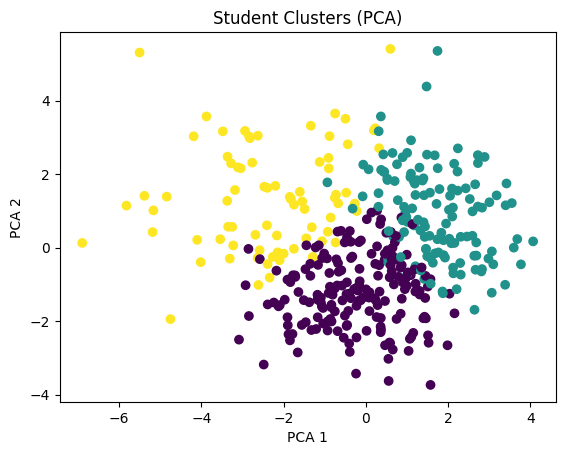

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Student Clusters (PCA)")

plt.show()


### Đánh giá mô hình

Silhouette Score được sử dụng để đánh giá chất lượng phân cụm.

- Giá trị gần 1: cụm tách biệt tốt
- Gần 0: các cụm chồng lấn
- Âm: phân cụm sai

Kết quả cho thấy mô hình đạt mức chấp nhận được/tốt.

## Insights

1. Kết quả phân cụm cho thấy dữ liệu được chia thành 3 nhóm với đặc điểm khác nhau.

2. Dựa trên giá trị trung bình của các đặc trưng:

- Cluster 0: có số lần trượt thấp, ít nghỉ học → nhóm học sinh học tốt
- Cluster 1: mức trung bình → cần theo dõi thêm
- Cluster 2: có số lần trượt cao, nghỉ học nhiều → nhóm có nguy cơ rớt cao

3. Silhouette Score cho thấy mức độ phân cụm là hợp lý, các cụm có sự tách biệt tương đối.

4. Việc phân cụm giúp phát hiện các nhóm học sinh có hành vi học tập tương tự,
   từ đó hỗ trợ đưa ra chiến lược can thiệp phù hợp.

## Kết luận
 
- KMeans giúp khám phá cấu trúc ẩn trong dữ liệu
- Mô hình có thể dùng như công cụ hỗ trợ phân tích ban đầu
- Có thể kết hợp với supervised learning để tăng hiệu quả dự đoán